# 02. 구급상황관리현황 EDA (2019~2023)

**대상 파일:** `구급상황관리현황/구급상황관리 현황_{연도}_전국.csv` (2019~2023, 각 ~230~300MB)

**목표:** 의료지도 패턴 분석 — 증상·중증도·지역·시간별 의료지도 현황

**전략:** 연도별 5,000행 샘플링 → 합산 (총 25,000행) 으로 빠르게 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('../data/구급상황관리현황')
SAMPLE_N = 5000

print('데이터 경로:', DATA_DIR.resolve())
files = sorted(DATA_DIR.glob('*.csv'))
print(f'발견된 파일 수: {len(files)}개')
for f in files:
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name}: {size_mb:.1f} MB')

데이터 경로: D:\DMU\빅데이터분석프로젝트\BigdataAnalysis-project\data\구급상황관리현황
발견된 파일 수: 5개
  구급상황관리 현황_2019_전국.csv: 223.9 MB
  구급상황관리 현황_2020_전국.csv: 222.7 MB
  구급상황관리 현황_2021_전국.csv: 253.1 MB
  구급상황관리 현황_2022_전국.csv: 296.8 MB
  구급상황관리 현황_2023_전국.csv: 256.2 MB


## 1. 구조 파악 — 2022년 파일 샘플 (5행)

In [2]:
latest_file = sorted(files)[-2]  # 2022년 파일 (2023년보다 앞)
print(f'파일: {latest_file.name}')

df_peek = pd.read_csv(latest_file, nrows=5)
print(f'컬럼 수: {df_peek.shape[1]}')
print('\n컬럼 목록:')
for i, col in enumerate(df_peek.columns):
    print(f'  [{i:2d}] {col}')

파일: 구급상황관리 현황_2022_전국.csv
컬럼 수: 26

컬럼 목록:
  [ 0] MDLCR_DSCSN_SN
  [ 1] MAIN_SYM_NM
  [ 2] SRIL_CLSF_NM
  [ 3] CTPV_NM
  [ 4] SGG_NM
  [ 5] EMD_NM
  [ 6] MDLCR_DSCSN_BGNG_DT
  [ 7] MDLCR_DSCSN_BGNG_YMD
  [ 8] MDLCR_DSCSN_BGNG_TM
  [ 9] MDLCR_DSCSN_BGNG_YR
  [10] MDLCR_DSCSN_BGNG_MM
  [11] MDLCR_DSCSN_BGNG_DAY
  [12] MDLCR_DSCSN_BGNG_HR
  [13] MDLCR_DSCSN_BGNG_MN
  [14] DCLR_DOW
  [15] SEASN_NM
  [16] QTR_NO
  [17] MDLCR_DSCSN_END_DT
  [18] MDLCR_DSCSN_END_YMD
  [19] MDLCR_DSCSN_END_TM
  [20] MDLCR_DSCSN_END_YR
  [21] MDLCR_DSCSN_END_MM
  [22] MDLCR_DSCSN_END_DAY
  [23] MDLCR_DSCSN_END_HR
  [24] MDLCR_DSCSN_END_MN
  [25] CNTR_NM


In [3]:
df_peek.T  # 행/열 전치

,0,1,2,3,4
MDLCR_DSCSN_SN,26000002022030200273,41000002022030200217,48000002022030200043,26000002022030200276,29000002022030200033
MAIN_SYM_NM,NaN,NaN,NaN,NaN,NaN
SRIL_CLSF_NM,NaN,NaN,NaN,NaN,NaN
CTPV_NM,부산광역시,경기도,경상남도,부산광역시,광주광역시
SGG_NM,해운대구,용인시 기흥구,김해시,사하구,북구
EMD_NM,좌동,신갈동,외동,다대동,풍향동
MDLCR_DSCSN_BGNG_DT,20220302062327,20220302062436,20220302064218,20220302062806,20220302063320
MDLCR_DSCSN_BGNG_YMD,20220302,20220302,20220302,20220302,20220302
MDLCR_DSCSN_BGNG_TM,62327,62436,64218,62806,63320
MDLCR_DSCSN_BGNG_YR,2022,2022,2022,2022,2022


## 2. 전체 연도 샘플 합산 로드

In [4]:
dfs = []
for f in files:
    # 파일명에서 연도 추출
    import re
    year_match = re.search(r'(\d{4})', f.stem)
    year = int(year_match.group(1)) if year_match else 0
    
    df_temp = pd.read_csv(f, nrows=SAMPLE_N)
    df_temp['_year'] = year
    dfs.append(df_temp)
    print(f'  {f.name}: {len(df_temp):,}행 로드 완료')

df = pd.concat(dfs, ignore_index=True)
print(f'\n합산 데이터: {df.shape[0]:,}행 × {df.shape[1]}열')

  구급상황관리 현황_2019_전국.csv: 5,000행 로드 완료
  구급상황관리 현황_2020_전국.csv: 5,000행 로드 완료
  구급상황관리 현황_2021_전국.csv: 5,000행 로드 완료
  구급상황관리 현황_2022_전국.csv: 5,000행 로드 완료
  구급상황관리 현황_2023_전국.csv: 5,000행 로드 완료

합산 데이터: 25,000행 × 27열


## 3. 기본 EDA

In [5]:
print('데이터 타입:')
print(df.dtypes.value_counts())
print('\n결측값 현황:')
null_info = df.isnull().sum()
print(null_info[null_info > 0].sort_values(ascending=False))

데이터 타입:
int64     18
object     9
Name: count, dtype: int64

결측값 현황:
CNTR_NM         19200
SRIL_CLSF_NM    18249
MAIN_SYM_NM     16569
EMD_NM           6899
SGG_NM           6808
CTPV_NM            14
dtype: int64


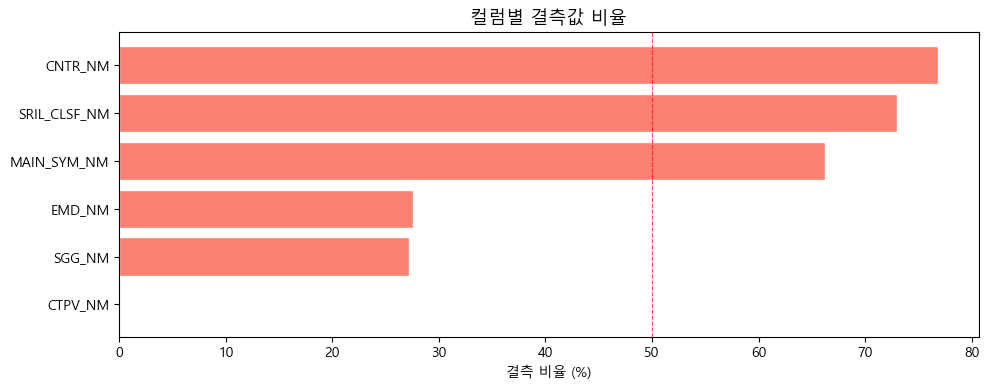

In [6]:
# 결측값 시각화
null_rate = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_nonzero = null_rate[null_rate > 0]

if len(null_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_nonzero)*0.4)))
    ax.barh(null_nonzero.index[::-1], null_nonzero.values[::-1], color='salmon', edgecolor='white')
    ax.set_xlabel('결측 비율 (%)')
    ax.set_title('컬럼별 결측값 비율', fontsize=13)
    ax.axvline(50, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('결측값 없음')

## 4. 연도별 의료지도 건수 추이

연도 컬럼: MDLCR_DSCSN_BGNG_YR


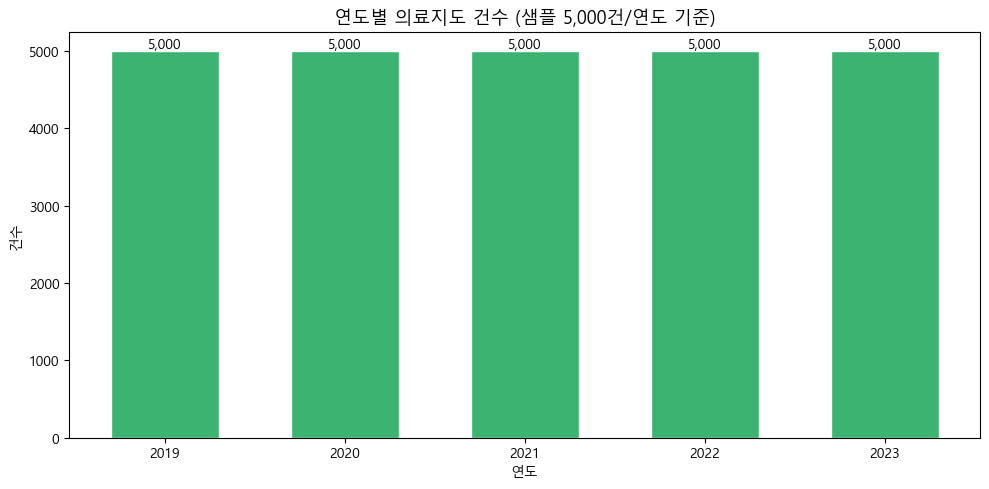

In [7]:
year_col = 'MDLCR_DSCSN_BGNG_YR' if 'MDLCR_DSCSN_BGNG_YR' in df.columns else '_year'
print(f'연도 컬럼: {year_col}')

yearly = df.groupby(year_col).size()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values,
              color='mediumseagreen', edgecolor='white', width=0.6)
ax.set_title(f'연도별 의료지도 건수 (샘플 {SAMPLE_N:,}건/연도 기준)', fontsize=13)
ax.set_xlabel('연도')
ax.set_ylabel('건수')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. 시간 패턴 분석

사용 가능한 시간 패턴 컬럼: ['MDLCR_DSCSN_BGNG_HR', 'MDLCR_DSCSN_BGNG_MM', 'DCLR_DOW', 'SEASN_NM']


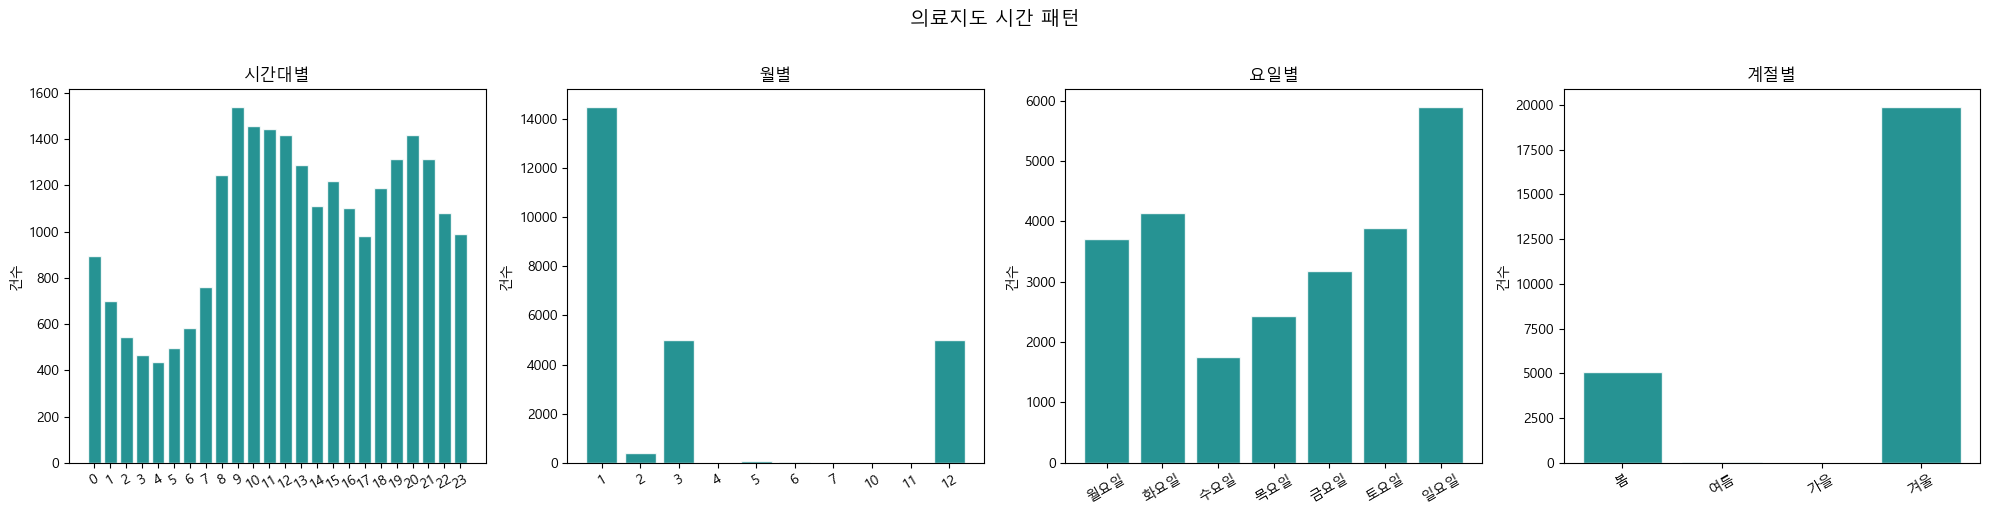

In [8]:
time_pattern_cols = {
    'MDLCR_DSCSN_BGNG_HR': '시간대별',
    'MDLCR_DSCSN_BGNG_MM': '월별',
    'DCLR_DOW': '요일별',
    'SEASN_NM': '계절별',
}

available = {k: v for k, v in time_pattern_cols.items() if k in df.columns}
print('사용 가능한 시간 패턴 컬럼:', list(available.keys()))

n = len(available)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]
    
    for ax, (col, label) in zip(axes, available.items()):
        counts = df[col].value_counts().sort_index()
        
        if col == 'DCLR_DOW':
            order = ['월요일','화요일','수요일','목요일','금요일','토요일','일요일']
            counts = counts.reindex([o for o in order if o in counts.index])
        elif col == 'SEASN_NM':
            order = ['봄', '여름', '가을', '겨울']
            counts = counts.reindex([o for o in order if o in counts.index])
        
        ax.bar(counts.index.astype(str), counts.values, color='teal', edgecolor='white', alpha=0.85)
        ax.set_title(label, fontsize=12)
        ax.set_ylabel('건수')
        ax.tick_params(axis='x', rotation=30)
    
    plt.suptitle('의료지도 시간 패턴', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 6. 증상 분석

SRIL_CLSF_NM 값 분포:
SRIL_CLSF_NM
응급        2676
비응급       2453
긴급         924
지연(사망)     400
대상외        298
Name: count, dtype: int64


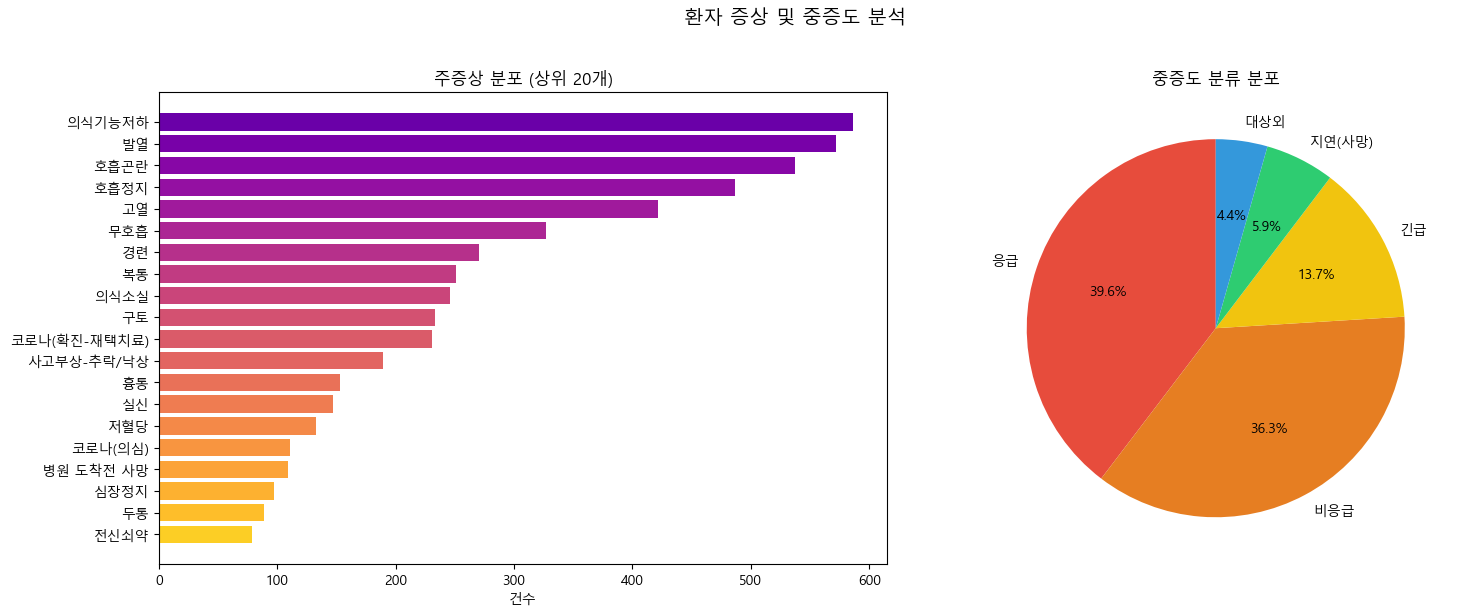

In [9]:
sym_col = 'MAIN_SYM_NM'
sril_col = 'SRIL_CLSF_NM'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 주증상 상위 20개
if sym_col in df.columns:
    sym_counts = df[sym_col].value_counts().head(20)
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(sym_counts)))
    axes[0].barh(sym_counts.index[::-1], sym_counts.values[::-1], color=colors[::-1])
    axes[0].set_title('주증상 분포 (상위 20개)', fontsize=12)
    axes[0].set_xlabel('건수')
else:
    axes[0].text(0.5, 0.5, f'컬럼 없음: {sym_col}', ha='center', va='center', transform=axes[0].transAxes)

# 중증도 분류
if sril_col in df.columns:
    sril_counts = df[sril_col].value_counts()
    print(f'{sril_col} 값 분포:')
    print(sril_counts)
    
    colors_sril = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
    axes[1].pie(sril_counts, labels=sril_counts.index, autopct='%1.1f%%',
                colors=colors_sril[:len(sril_counts)], startangle=90,
                textprops={'fontsize': 10})
    axes[1].set_title('중증도 분류 분포', fontsize=12)
else:
    axes[1].text(0.5, 0.5, f'컬럼 없음: {sril_col}', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('환자 증상 및 중증도 분석', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. 지역별 의료지도 분포

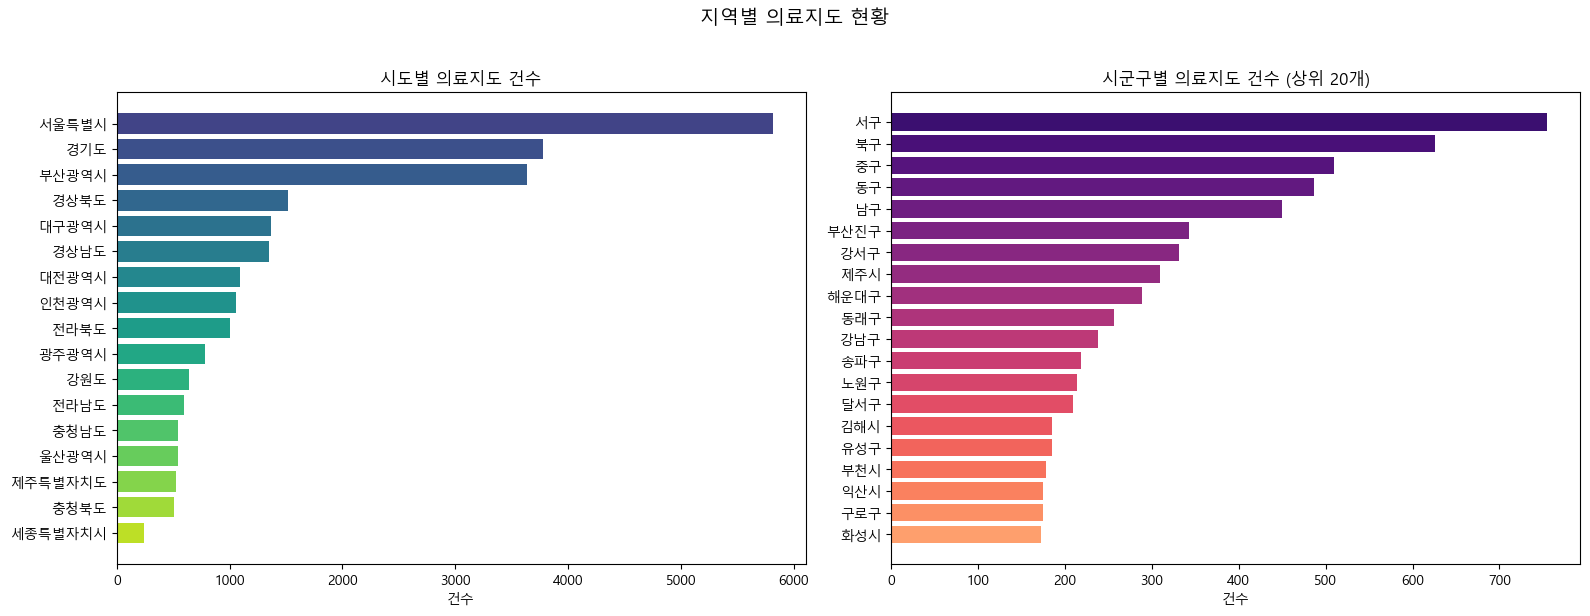

In [10]:
ctpv_col = 'CTPV_NM'
sgg_col = 'SGG_NM'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시도별
if ctpv_col in df.columns:
    ctpv_counts = df[ctpv_col].value_counts().head(17)
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(ctpv_counts)))
    axes[0].barh(ctpv_counts.index[::-1], ctpv_counts.values[::-1], color=colors[::-1])
    axes[0].set_title('시도별 의료지도 건수', fontsize=12)
    axes[0].set_xlabel('건수')
else:
    axes[0].text(0.5, 0.5, f'컬럼 없음: {ctpv_col}', ha='center', va='center', transform=axes[0].transAxes)

# 시군구별 상위 20개
if sgg_col in df.columns:
    sgg_counts = df[sgg_col].value_counts().head(20)
    colors2 = plt.cm.magma(np.linspace(0.2, 0.8, len(sgg_counts)))
    axes[1].barh(sgg_counts.index[::-1], sgg_counts.values[::-1], color=colors2[::-1])
    axes[1].set_title('시군구별 의료지도 건수 (상위 20개)', fontsize=12)
    axes[1].set_xlabel('건수')
else:
    axes[1].text(0.5, 0.5, f'컬럼 없음: {sgg_col}', ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('지역별 의료지도 현황', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. 의료지도 소요시간 분석

소요시간 파싱 성공: 24,749건
중앙값: 1.9분
평균: 2.9분
90th 백분위: 5.7분


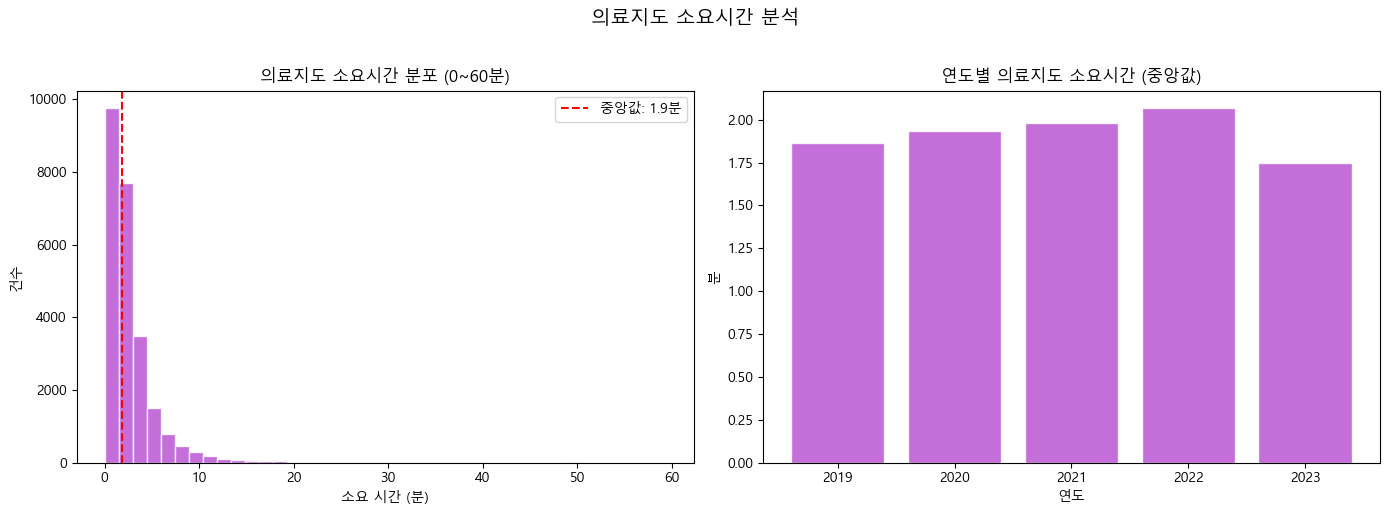

In [11]:
bgng_col = 'MDLCR_DSCSN_BGNG_DT'
end_col = 'MDLCR_DSCSN_END_DT'

if bgng_col in df.columns and end_col in df.columns:
    df['시작시간'] = pd.to_datetime(df[bgng_col].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
    df['종료시간'] = pd.to_datetime(df[end_col].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
    df['소요시간(분)'] = (df['종료시간'] - df['시작시간']).dt.total_seconds() / 60
    
    valid = df['소요시간(분)'].dropna()
    valid = valid[(valid >= 0) & (valid <= 60)]
    
    print(f'소요시간 파싱 성공: {len(valid):,}건')
    print(f'중앙값: {valid.median():.1f}분')
    print(f'평균: {valid.mean():.1f}분')
    print(f'90th 백분위: {valid.quantile(0.9):.1f}분')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(valid, bins=40, color='mediumorchid', edgecolor='white', alpha=0.85)
    axes[0].axvline(valid.median(), color='red', linestyle='--',
                    label=f'중앙값: {valid.median():.1f}분')
    axes[0].set_title('의료지도 소요시간 분포 (0~60분)', fontsize=12)
    axes[0].set_xlabel('소요 시간 (분)')
    axes[0].set_ylabel('건수')
    axes[0].legend()
    
    # 연도별 중앙 소요시간
    if '_year' in df.columns:
        yearly_time = df.groupby('_year')['소요시간(분)'].median()
        axes[1].bar(yearly_time.index.astype(str), yearly_time.values,
                    color='mediumorchid', edgecolor='white', alpha=0.85)
        axes[1].set_title('연도별 의료지도 소요시간 (중앙값)', fontsize=12)
        axes[1].set_xlabel('연도')
        axes[1].set_ylabel('분')
    
    plt.suptitle('의료지도 소요시간 분석', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f'시간 컬럼 없음: {bgng_col}, {end_col}')
    print('사용 가능한 컬럼:', [c for c in df.columns if 'DT' in c or 'YMD' in c])

## 9. 센터별 의료지도 건수

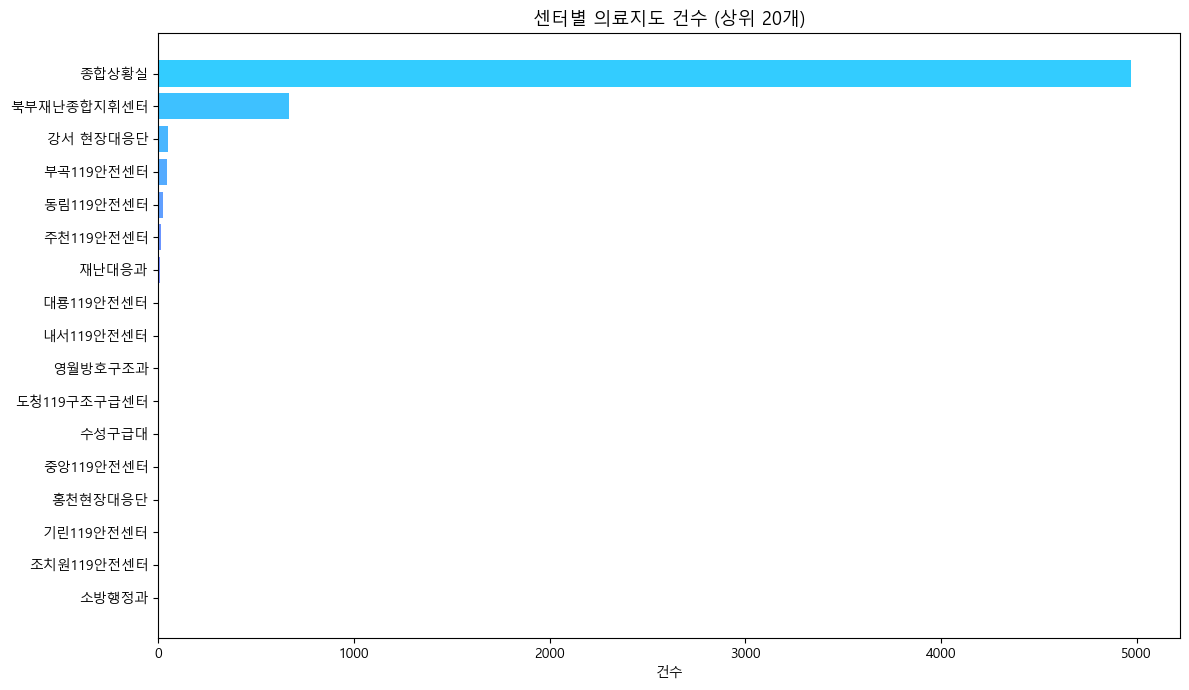

In [12]:
cntr_col = 'CNTR_NM'

if cntr_col in df.columns:
    cntr_counts = df[cntr_col].value_counts().head(20)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = plt.cm.cool(np.linspace(0.2, 0.9, len(cntr_counts)))
    ax.barh(cntr_counts.index[::-1], cntr_counts.values[::-1], color=colors[::-1])
    ax.set_title('센터별 의료지도 건수 (상위 20개)', fontsize=13)
    ax.set_xlabel('건수')
    plt.tight_layout()
    plt.show()
else:
    print(f'컬럼 없음: {cntr_col}')

## 10. 증상 × 중증도 교차 분석

증상 × 중증도 교차표:


SRIL_CLSF_NM,긴급,대상외,비응급,응급,지연(사망)
MAIN_SYM_NM,,,,,
경련,21,1,32,118,0
고열,4,4,95,68,0
구토,4,2,61,32,0
무호흡,152,5,0,26,38
발열,2,6,151,77,0
복통,4,0,79,32,0
의식기능저하,37,2,28,291,1
의식소실,36,1,6,95,1
호흡곤란,47,3,47,227,0


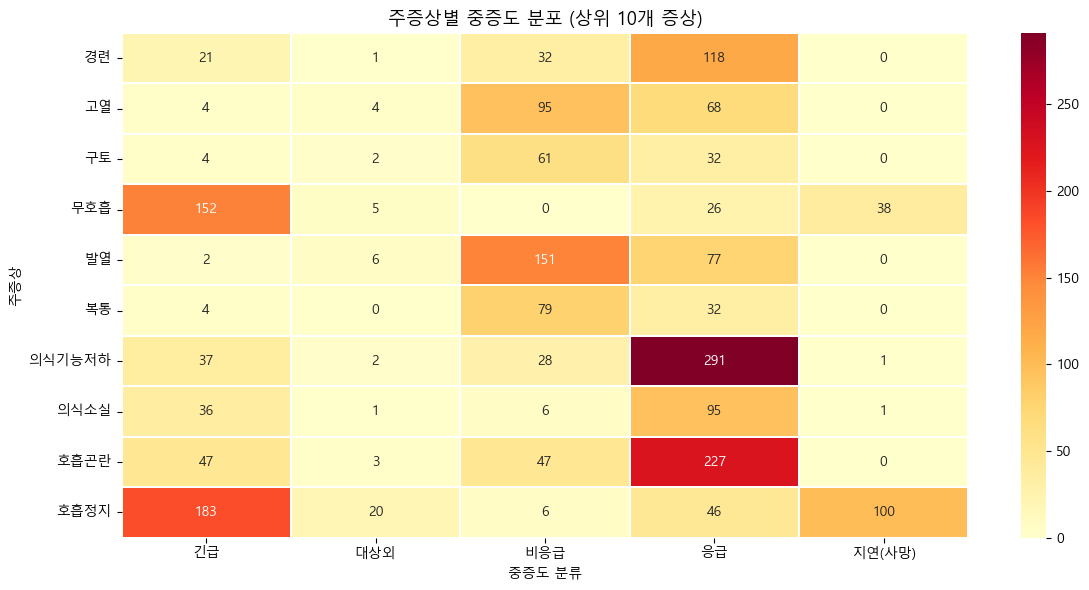

In [13]:
if sym_col in df.columns and sril_col in df.columns:
    top_syms = df[sym_col].value_counts().head(10).index
    cross = df[df[sym_col].isin(top_syms)].pivot_table(
        index=sym_col, columns=sril_col, aggfunc='size', fill_value=0
    )
    
    print('증상 × 중증도 교차표:')
    display(cross)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.3)
    ax.set_title('주증상별 중증도 분포 (상위 10개 증상)', fontsize=13)
    ax.set_xlabel('중증도 분류')
    ax.set_ylabel('주증상')
    plt.tight_layout()
    plt.show()
else:
    print(f'필요 컬럼 없음: {sym_col}, {sril_col}')

## 11. 요약 통계

In [14]:
print('=== 구급상황관리현황 EDA 요약 ===')
print(f'  분석 대상: 2019~2023년, 연도별 {SAMPLE_N:,}건 샘플')
print(f'  총 샘플 수: {len(df):,}건')
print(f'  컬럼 수: {df.shape[1]}개')

if ctpv_col in df.columns:
    print(f'  가장 많은 의료지도 지역: {df[ctpv_col].value_counts().index[0]}')

if sym_col in df.columns:
    print(f'  가장 많은 주증상: {df[sym_col].value_counts().index[0]}')

if '소요시간(분)' in df.columns:
    valid_time = df['소요시간(분)'].dropna()
    valid_time = valid_time[(valid_time >= 0) & (valid_time <= 60)]
    print(f'  의료지도 중앙 소요시간: {valid_time.median():.1f}분')

=== 구급상황관리현황 EDA 요약 ===
  분석 대상: 2019~2023년, 연도별 5,000건 샘플
  총 샘플 수: 25,000건
  컬럼 수: 30개
  가장 많은 의료지도 지역: 서울특별시
  가장 많은 주증상: 의식기능저하
  의료지도 중앙 소요시간: 1.9분
